# 11 — Feature selection: clusters + clustered permutation importance (WP2)

Stage 2 of the 3-stage feature-selection pipeline, on the **56 MODEL features** (stage-1
univariate ranking lives in `outputs/tables/feature_ranking_univariate.csv`). `vrp` /
`jpy_strength` also exist as routing triggers (handoff §5.4) — routing is **out of scope**
here: dropping model copies never touches the routing engine.

Method: hierarchical clustering on the development matrix (distance 1−|ρ|, average linkage,
cut t=0.4), then cluster importance = mean drop over 20 seeded repeats of the soft-median
ensemble **val AUC-PR** when all columns of the cluster are jointly row-shuffled in the val
matrix. Permutation = re-scoring only (models fit once per fold and kept; reference percentile
distributions untouched). Cross-fold aggregation is n_pos-weighted. No holdout contact.

In [1]:
import os, sys, time
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.feature_selection import (correlation_cluster_count, correlation_clusters,
                                   clustered_permutation_importance,
                                   plot_cluster_importance)
pd.set_option('display.width', 160)

## Correlation clusters (development matrix, 1−|ρ|, average linkage)

In [2]:
print('cluster counts by cut:', correlation_cluster_count())  # t=0.4 expected ~36
clusters = correlation_clusters(threshold=0.4)   # -> outputs/tables/feature_clusters.csv
sizes = clusters.groupby('cluster_id').size()
print(f'{clusters.cluster_id.nunique()} clusters at t=0.4 '
      f'({(sizes == 1).sum()} singletons, largest = {sizes.max()})')
multi = (clusters.groupby('cluster_id')['feature'].apply('|'.join)
         .loc[sizes[sizes > 1].index].rename('members').to_frame())
multi

cluster counts by cut: {0.3: 44, 0.4: 36, 0.5: 26}
36 clusters at t=0.4 (22 singletons, largest = 4)


,members
cluster_id,
1,em_spread|hy_ig_spread|us_de_10y
4,de_term_10y_2y|us_term_10y_2y
7,GTITL10YR|GTITL2YR|GTITL30YR
11,DXY|GBP
15,equity_bond_rot|hy_ig_spread_chg4w
18,CRY|Cl1
19,EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU
20,MXBR|MXRU
21,MXCN|MXIN


## Clustered permutation importance
Per fold: fit the 4 detectors once (leakage-free, fresh per-fold scalers), keep them;
20 joint row-shuffles per cluster; drop in soft-median ensemble val AUC-PR; n_pos-weighted
aggregation across the 5 folds. ~3 min (5 AE fits + batched re-scoring).

In [3]:
t0 = time.time()
imp = clustered_permutation_importance(clusters)  # -> outputs/tables/cluster_importance.csv
print(f'{time.time()-t0:.0f}s')
imp.head(12)[['cluster_id', 'members', 'n_members', 'mean_drop', 'std_drop']]

fold 1: baseline AUC-PR=0.672, 36 clusters x 20 repeats done


fold 2: baseline AUC-PR=0.647, 36 clusters x 20 repeats done


fold 3: baseline AUC-PR=0.032, 36 clusters x 20 repeats done


fold 4: baseline AUC-PR=0.166, 36 clusters x 20 repeats done


fold 5: baseline AUC-PR=0.368, 36 clusters x 20 repeats done
220s


,cluster_id,members,n_members,mean_drop,std_drop
0,3,it_de_10y,1,0.098482,0.023879
1,8,it_de_10y_chg4w,1,0.035024,0.023866
2,19,EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU,4,0.023582,0.010632
3,15,equity_bond_rot|hy_ig_spread_chg4w,2,0.010813,0.005917
4,26,GT10|LUACTRUU|LUMSTRUU|USGG2YR,4,0.008115,0.007852
5,20,MXBR|MXRU,2,0.007054,0.006764
6,7,GTITL10YR|GTITL2YR|GTITL30YR,3,0.006344,0.017829
7,33,US0001M,1,0.005932,0.005390
8,21,MXCN|MXIN,2,0.005763,0.005157
9,24,GTDEM10Y|GTGBP30Y,2,0.005718,0.007509


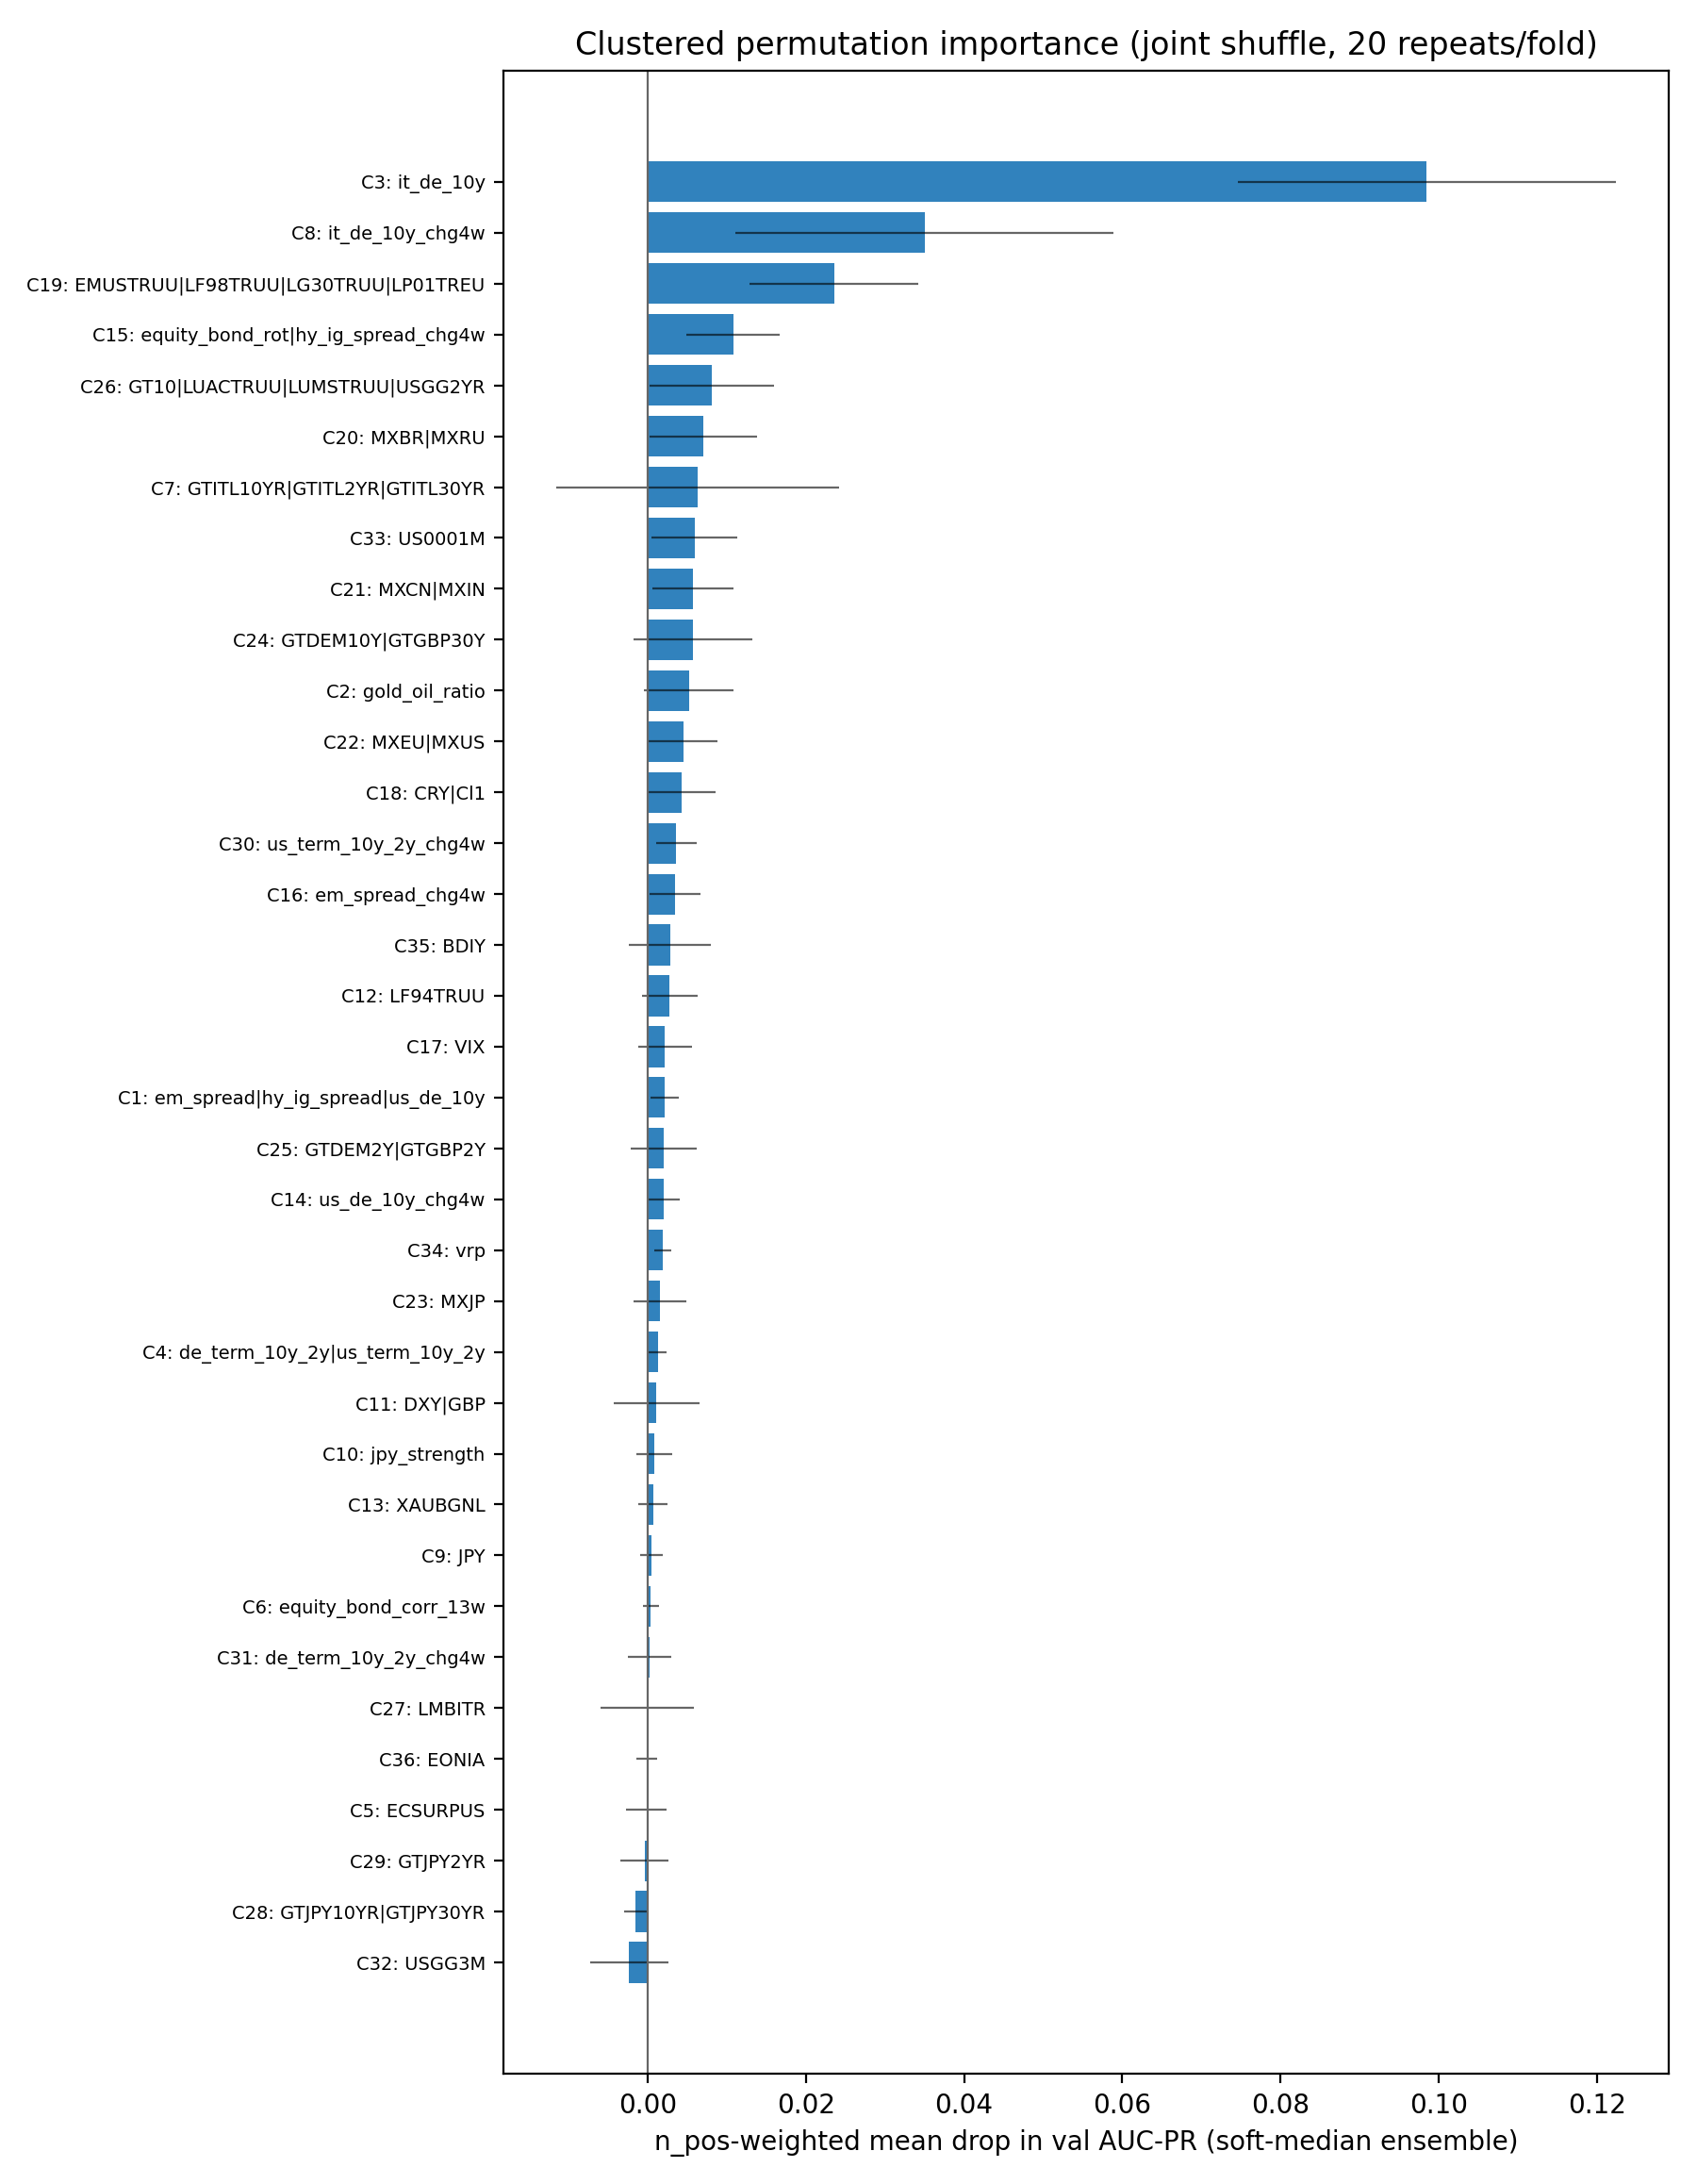

In [4]:
fig_path = plot_cluster_importance(imp)   # -> outputs/figures/cluster_importance.png
from IPython.display import Image
Image(filename=str(fig_path), width=900)

## Sanity check (pre-registered expectation)
Clusters containing **VIX**, **it_de_10y** and the **credit block** are expected near the top.

In [5]:
ranked = imp.reset_index(drop=True).assign(rank=lambda d: d.index + 1)
def where(token):
    hit = ranked[ranked['members'].str.contains(token)].iloc[0]
    return int(hit['rank']), hit['members'], hit['mean_drop']
for token in ['it_de_10y', 'LF98TRUU', 'hy_ig_spread', 'VIX']:
    r, m, d = where(token)
    tag = 'PASS' if r <= 10 else 'ATTENTION'
    print(f'[{tag}] {token:<14} -> rank {r:>2}/36  drop={d:+.4f}  cluster: {m}')

[PASS] it_de_10y      -> rank  1/36  drop=+0.0985  cluster: it_de_10y
[PASS] LF98TRUU       -> rank  3/36  drop=+0.0236  cluster: EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU
[PASS] hy_ig_spread   -> rank  4/36  drop=+0.0108  cluster: equity_bond_rot|hy_ig_spread_chg4w
[ATTENTION] VIX            -> rank 18/36  drop=+0.0022  cluster: VIX


### Discussion — the VIX cluster is NOT near the top, and that is informative
`it_de_10y` (rank 1, drop ≈ 0.09) and the credit block `EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU`
(rank 3) behave as expected, as does the rotation/credit-momentum cluster
`equity_bond_rot|hy_ig_spread_chg4w` (rank 4). **VIX does not** (rank ~22, drop ≈ 0): at t=0.4 it
is a *singleton* cluster, but its strongest development-set correlates — `hy_ig_spread` (|ρ|≈0.56),
`us_de_10y` (≈0.54), `equity_bond_rot` (≈0.46) — sit just **below** the |ρ|>0.6 merge threshold and
live in clusters that stay intact when VIX is shuffled. The four detectors are unsupervised: with 55
intact columns carrying nearly the same stress signal, permuting VIX alone barely moves the
anomaly geometry, so its *marginal* importance collapses even though its stage-1 *univariate* AP is
the best of all 56 (0.749). This is the classic correlated-features caveat of permutation importance
— and exactly why stage 3 picks cluster *representatives* (VIX still enters subsets through its own
cluster representative: itself) rather than thresholding on this ranking alone.

# Part 2 — Stage 3: representatives, nested subset curve, freeze, single holdout shot (WP3)

* **Representative per cluster** = member with the highest stage-1 `AP_best_w`; extendability
  tie-break: if the top member is in `HARD_TO_EXTEND` = {MXRU, EONIA, ECSURPUS, US0001M, BDIY}
  and the runner-up is within 0.05 AP, take the runner-up. Every choice is recorded with its
  reason in `outputs/tables/cluster_representatives.csv`.
* **HYPOTHESIS_KEPT** = {`equity_bond_corr_13w`}: *discriminates inflation-driven crises; regime
  absent in-sample; expected value is out-of-sample*. Always included in every subset and
  reported separately in all tables.
* For k ∈ {8, 12, 16, 20, 26, 36} ∪ {ALL}: fresh `FoldScaler` per subset (`feature_cols_` locks on
  first call — handoff §7a), the 4 detectors re-fit per fold, per-model thresholds tuned exactly as
  the production code does, then `EnsembleDetector('soft_median', …).fit_threshold_walkforward`
  → per-subset τ_k + weighted-CV metrics.
* **Knee rule, pre-registered** (fixed before seeing results): smallest k whose weighted-CV AUC-PR
  ≥ 0.98 × the max over all evaluated subsets. The frozen list goes to
  `outputs/tables/selected_features.json`, and only then the sealed 2019-2021 holdout is
  evaluated **once**. No iteration afterwards.

In [6]:
from src.feature_selection import (HARD_TO_EXTEND, HYPOTHESIS_KEPT, KNEE_FRACTION,
                                   cluster_representatives, subset_curve,
                                   freeze_selected_features, evaluate_frozen_on_holdout,
                                   plot_subset_curve)
reps = cluster_representatives(clusters)   # -> outputs/tables/cluster_representatives.csv
tie_breaks = reps[reps['representative'] != reps['top_member']]
kept_hard = reps[(reps['representative'] == reps['top_member'])
                 & reps['top_member'].isin(HARD_TO_EXTEND)]
print(f'{len(reps)} representatives | tie-break applied: {len(tie_breaks)} | '
      f'hard-to-extend kept as-is: {len(kept_hard)}')
print('\nHYPOTHESIS_KEPT:', HYPOTHESIS_KEPT)
cols = ['cluster_id', 'representative', 'AP_best_w', 'top_member', 'top_AP_best_w', 'reason']
display(tie_breaks[cols] if len(tie_breaks) else 'no tie-breaks triggered')
display(kept_hard[cols] if len(kept_hard) else 'no hard-to-extend tops kept')

36 representatives | tie-break applied: 1 | hard-to-extend kept as-is: 4

HYPOTHESIS_KEPT: {'equity_bond_corr_13w': 'discriminates inflation-driven crises; regime absent in-sample; expected value is out-of-sample'}


,cluster_id,representative,AP_best_w,top_member,top_AP_best_w,reason
19,20,MXBR,0.566239,MXRU,0.574988,runner-up within 0.05 AP of hard-to-extend top...


,cluster_id,representative,AP_best_w,top_member,top_AP_best_w,reason
4,5,ECSURPUS,0.459192,ECSURPUS,0.459192,hard-to-extend top kept: no runner-up in cluster
32,33,US0001M,0.509076,US0001M,0.509076,hard-to-extend top kept: no runner-up in cluster
34,35,BDIY,0.497820,BDIY,0.497820,hard-to-extend top kept: no runner-up in cluster
35,36,EONIA,0.416167,EONIA,0.416167,hard-to-extend top kept: no runner-up in cluster


## Nested subset curve (~7 × ~2 min of leakage-free refits)

In [7]:
t0 = time.time()
curve = subset_curve(importance=imp, representatives=reps)  # -> outputs/tables/subset_curve.csv
print(f'total {time.time()-t0:.0f}s')
curve[['k', 'n_features', 'AUC_PR_wCV', 'F2_wCV', 'F1_wCV', 'tau_k', 'hypothesis_kept']]

k=  8:  9 features, AUC-PR_wCV=0.549, F2_wCV=0.698, tau=0.9722 (86s)


k= 12: 13 features, AUC-PR_wCV=0.565, F2_wCV=0.720, tau=0.9837 (90s)


k= 16: 17 features, AUC-PR_wCV=0.562, F2_wCV=0.723, tau=0.9855 (83s)


k= 20: 21 features, AUC-PR_wCV=0.550, F2_wCV=0.718, tau=0.9846 (93s)


k= 26: 27 features, AUC-PR_wCV=0.557, F2_wCV=0.743, tau=0.9828 (75s)


k= 36: 36 features, AUC-PR_wCV=0.588, F2_wCV=0.732, tau=0.9551 (71s)


k=ALL: 56 features, AUC-PR_wCV=0.599, F2_wCV=0.712, tau=0.9783 (98s)
total 596s


,k,n_features,AUC_PR_wCV,F2_wCV,F1_wCV,tau_k,hypothesis_kept
0,8,9,0.549302,0.698163,0.581380,0.972205,equity_bond_corr_13w
1,12,13,0.565090,0.720347,0.608405,0.983678,equity_bond_corr_13w
2,16,17,0.561909,0.723018,0.608381,0.985489,equity_bond_corr_13w
3,20,21,0.549607,0.717854,0.609923,0.984637,equity_bond_corr_13w
4,26,27,0.557304,0.743175,0.636847,0.982790,equity_bond_corr_13w
5,36,36,0.588416,0.732082,0.618361,0.955136,equity_bond_corr_13w
6,ALL,56,0.598578,0.711980,0.639573,0.978254,equity_bond_corr_13w


knee rule: smallest k with AUC_PR_wCV >= 0.98 * max (threshold 0.5866)
chosen k = 36 -> 35 data-driven + 1 hypothesis features, tau = 0.9551
data_driven: ['BDIY', 'Cl1', 'ECSURPUS', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTGBP2Y', 'GTITL10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LMBITR', 'LP01TREU', 'MXBR', 'MXCN', 'MXJP', 'MXUS', 'US0001M', 'USGG3M', 'VIX', 'XAUBGNL', 'de_term_10y_2y', 'de_term_10y_2y_chg4w', 'em_spread_chg4w', 'equity_bond_rot', 'gold_oil_ratio', 'hy_ig_spread', 'it_de_10y', 'it_de_10y_chg4w', 'jpy_strength', 'us_de_10y_chg4w', 'us_term_10y_2y_chg4w', 'vrp']
hypothesis : ['equity_bond_corr_13w']


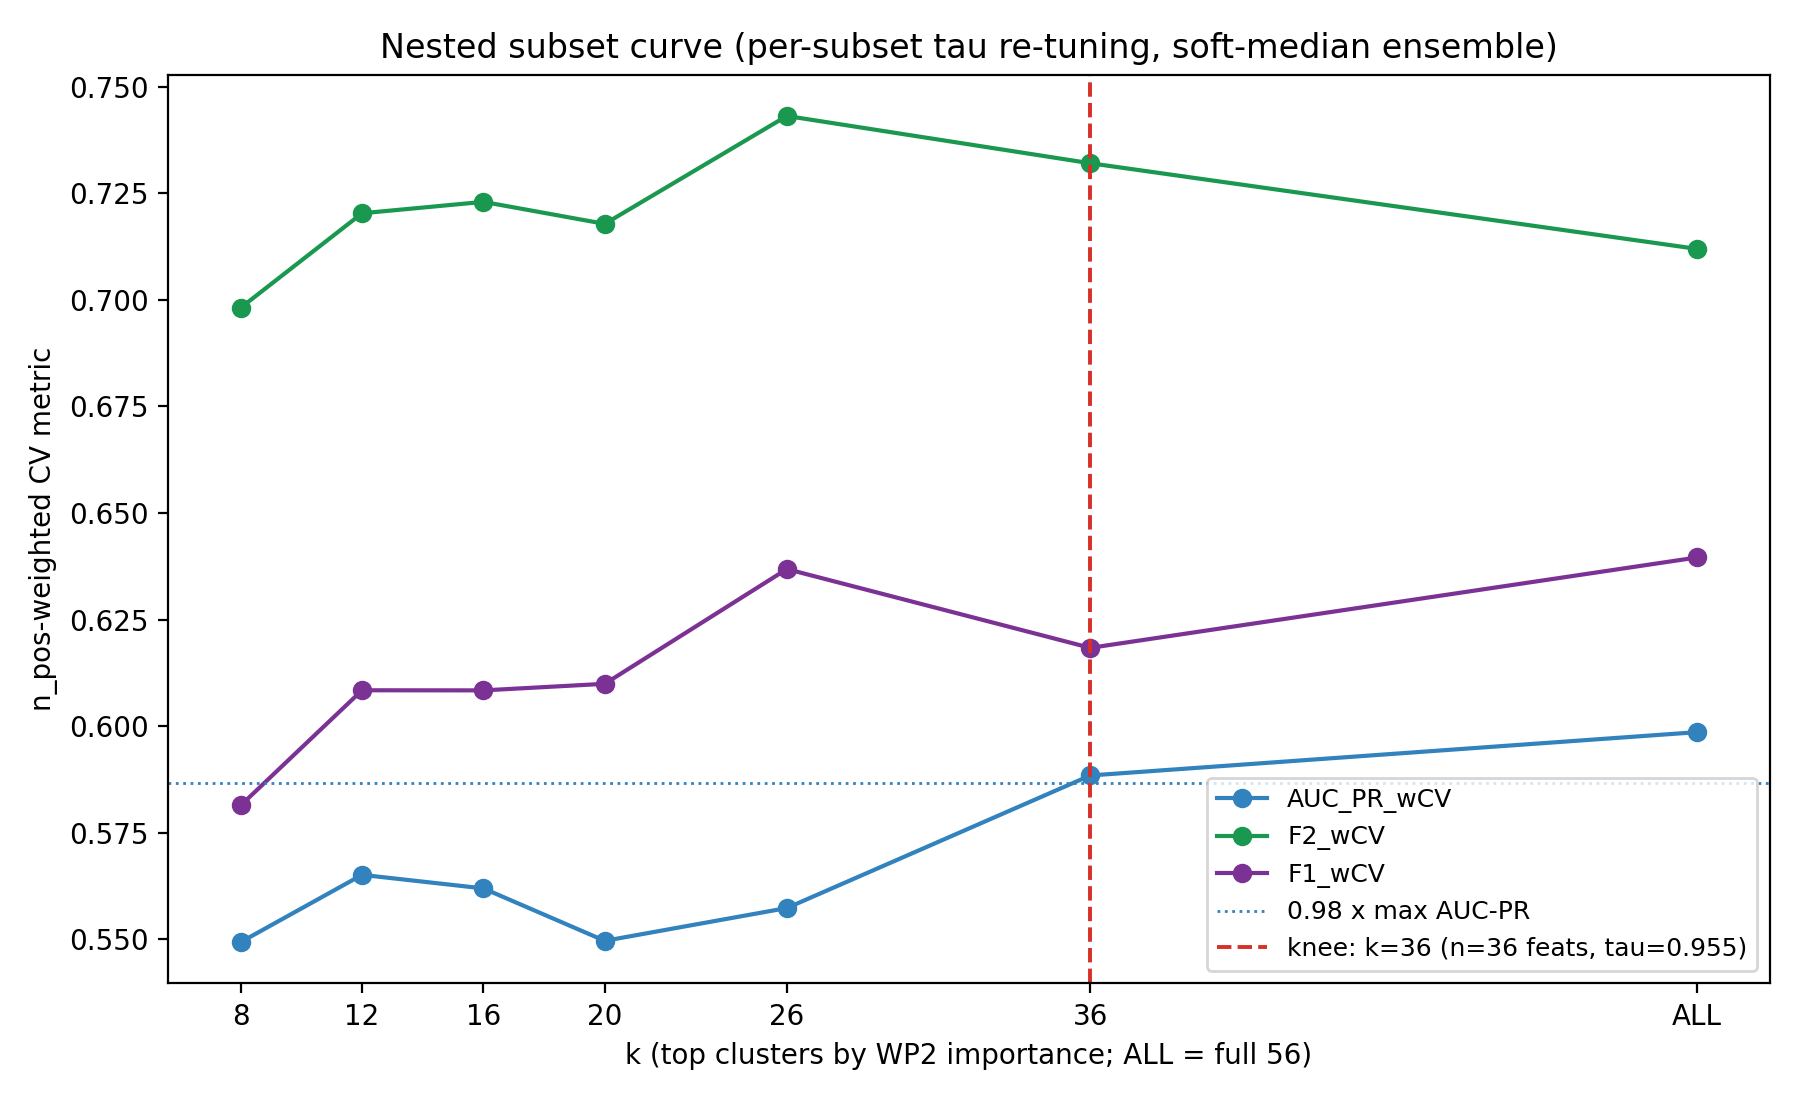

In [8]:
selected = freeze_selected_features(curve)  # -> outputs/tables/selected_features.json (FROZEN)
print('knee rule:', selected['knee_rule'])
print(f"chosen k = {selected['k']} -> {len(selected['data_driven'])} data-driven + "
      f"{len(selected['hypothesis'])} hypothesis features, tau = {selected['tau']:.4f}")
print('data_driven:', selected['data_driven'])
print('hypothesis :', selected['hypothesis'])
fig_path = plot_subset_curve(curve, selected)  # -> outputs/figures/subset_curve.png
from IPython.display import Image
Image(filename=str(fig_path), width=850)

## THE single sealed-holdout shot (2019-2021)
Feature list and τ are frozen above. Dev-fit scaler + dev-fit models, subset-restricted, same
inference path as handoff §2; side-by-side with the full-56 production row (saved final models via
the WP1 final-path cache). **If the frozen subset underperforms, that is a finding to report, not
to fix** — no second shot.

In [9]:
holdout = evaluate_frozen_on_holdout(selected)  # -> outputs/tables/holdout_frozen_vs_full.csv
display(holdout.round(3))
f, g = holdout.iloc[0], holdout.iloc[1]
print('verdict (frozen - full_56):')
for m in ['F1', 'F_beta_2', 'AUC_PR', 'AUC_ROC', 'Precision', 'Recall']:
    d = f[m] - g[m]
    print(f'  {m:<10} {f[m]:.3f} vs {g[m]:.3f}  ({d:+.3f})')
print(f'  flagged weeks: {int(f["n_flagged"])} vs {int(g["n_flagged"])} of 121')

,subset,n_features,tau,n_flagged,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,frozen_k36,36,0.955,20,0.651,0.7,0.609,0.881,0.784,0.625
1,full_56,56,0.977,11,0.647,1.0,0.478,0.860,0.753,0.534


verdict (frozen - full_56):
  F1         0.651 vs 0.647  (+0.004)
  F_beta_2   0.625 vs 0.534  (+0.091)
  AUC_PR     0.784 vs 0.753  (+0.031)
  AUC_ROC    0.881 vs 0.860  (+0.021)
  Precision  0.700 vs 1.000  (-0.300)
  Recall     0.609 vs 0.478  (+0.130)
  flagged weeks: 20 vs 11 of 121


**Reading the result.** The deltas above are reported exactly as they came out of the single
pre-registered shot. Positive deltas mean the frozen subset transfers better out-of-sample than
the full 56; negative deltas are the price of parsimony/extendability and are **left as a
finding** — the frozen list in `selected_features.json` is not revisited.